# Netflix Data Analytics Project

Complete Capstone Notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
print(df.shape)
df.info()
df.isnull().sum()

(8807, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [4]:
df.drop_duplicates(inplace=True)
df['director']=df['director'].fillna('Unknown')
df['cast']=df['cast'].fillna('Unknown')
df['country']=df['country'].fillna('Unknown')
df['date_added']=pd.to_datetime(df['date_added'], errors='coerce')
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,8807,8807,8807,8709,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4529,7693,749,NaN,NaN,17,220,514,8775
top,s1,Movie,Dick Johnson Is Dead,Unknown,Unknown,United States,NaN,NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,2634,825,2818,NaN,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-23 01:45:29.452290816,2014.180198,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,2008-01-01 00:00:00,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-20 00:00:00,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,2019-07-12 00:00:00,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,2020-08-26 00:00:00,2019.000000,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,2021-09-25 00:00:00,2021.000000,NaN,NaN,NaN,NaN


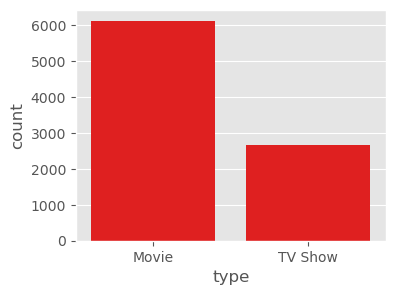

In [24]:
plt.figure(figsize=(4,3))
sns.countplot(data=df,x='type',color='red')
plt.show()

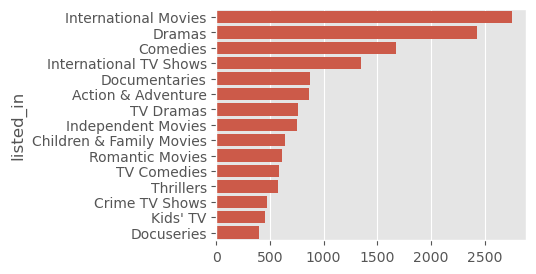

In [25]:

genres=df['listed_in'].str.split(', ').explode()
genre_counts=genres.value_counts().head(15)
plt.figure(figsize=(4,3))
sns.barplot(x=genre_counts.values,y=genre_counts.index)
plt.show()

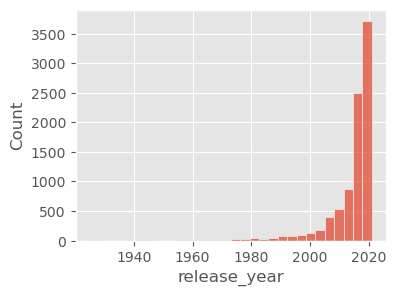

In [26]:
plt.figure(figsize=(4,3))
sns.histplot(df['release_year'],bins=30)
plt.show()

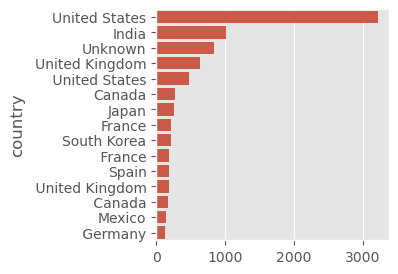

In [28]:
country_df=df.copy()
country_df['country']=country_df['country'].str.split(',')
country_df=country_df.explode('country')
top_country=country_df['country'].value_counts().head(15)
plt.figure(figsize=(3,3))
sns.barplot(x=top_country.values,y=top_country.index)
plt.show()

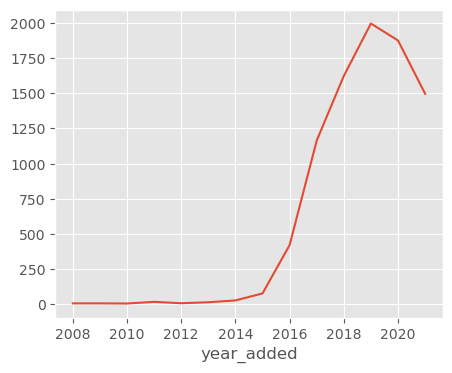

In [37]:
plt.figure(figsize=(5,4))
df['year_added']=df['date_added'].dt.year
df['year_added'].value_counts().sort_index().plot()
plt.show()

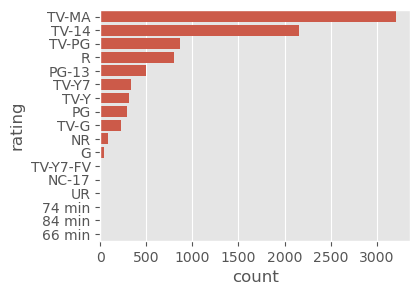

In [32]:
plt.figure(figsize=(4,3))
sns.countplot(data=df,y='rating',order=df['rating'].value_counts().index)
plt.show()

In [11]:
movies=df[df['type']=='Movie'].copy()
movies['duration_num']=pd.to_numeric(movies['duration'].str.replace(' min','',regex=False),errors='coerce')
movies['duration_num'].describe()

count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_num, dtype: float64

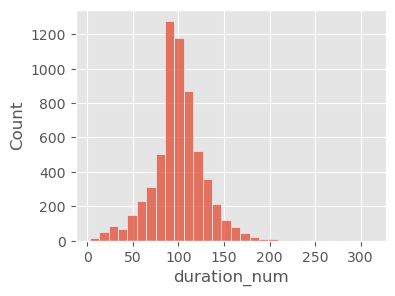

In [33]:
plt.figure(figsize=(4,3))
sns.histplot(movies['duration_num'].dropna(),bins=30)
plt.show()

In [13]:
df[['title','type','release_year']].sort_values('release_year',ascending=False).head(10)

,title,type,release_year
693,Ali & Ratu Ratu Queens,Movie,2021
781,Black Holes | The Edge of All We Know,Movie,2021
762,Sweet & Sour,Movie,2021
763,Sweet Tooth,TV Show,2021
764,Trippin' with the Kandasamys,Movie,2021
765,Xtreme,Movie,2021
766,Alan Saldaña: Locked Up,Movie,2021
767,Creator's File: GOLD,TV Show,2021
768,Dancing Queens,Movie,2021
770,Myriam Fares: The Journey,Movie,2021


In [19]:
genre_year = df.copy()

genre_year['genre'] = genre_year['listed_in'].fillna('Unknown').str.split(', ')
genre_year = genre_year.explode('genre').reset_index(drop=True)

print(genre_year.index.is_unique)  # Should now be True

True


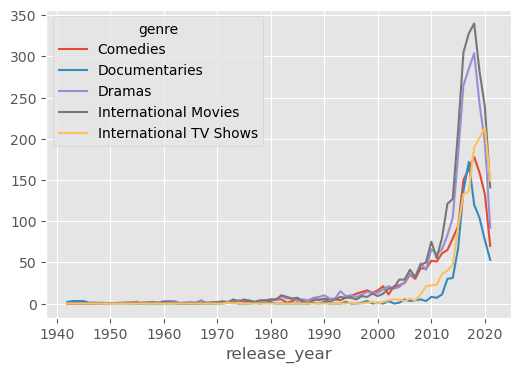

In [34]:
top_genres = genre_year['genre'].value_counts().head(5).index

filtered = genre_year[genre_year['genre'].isin(top_genres)]

pivot = pd.crosstab(
    filtered['release_year'],
    filtered['genre']
)

pivot.plot(figsize=(6,4))
plt.show()

              release_year  duration_num
release_year      1.000000     -0.206285
duration_num     -0.206285      1.000000


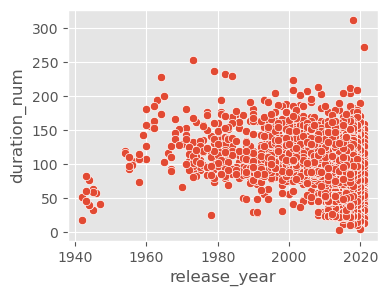

In [42]:
corr_df=movies[['release_year','duration_num']].dropna()
print(corr_df.corr())
plt.figure(figsize=(4,3))
sns.scatterplot(data=corr_df,x='release_year',y='duration_num')
plt.show()

In [16]:
print('Unique Genres:', genres.nunique())
print('Unique Ratings:', df['rating'].nunique())

Unique Genres: 42
Unique Ratings: 17


# Conclusions and Recommendations

- Movies dominate the Netflix catalog.
- Drama and International Movies are highly represented.
- Content growth accelerated after 2015.
- The United States contributes the largest share of content.

## Recommendations
- Invest in high-performing genres.
- Expand regional content.
- Use historical trends for future content planning.
